In [9]:
# run once in this env
%pip install -q cellpose

Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
from cellpose import models

In [11]:
NAME = "6bba_971fa5e0"
BASE = "/hpcstor6/scratch01/a/a.kanamarlapudi001/cell_tracking/biohub-cell-tracking-during-development/train"

vol = zarr.open(f"{BASE}/{NAME}.zarr", mode="r")["0"]
g = zarr.open(f"{BASE}/{NAME}.geff", mode="r")

nodes = pd.DataFrame({
    "id": g["nodes/ids"][:],
    "t": g["nodes/props/t/values"][:],
    "z": g["nodes/props/z/values"][:],
    "y": g["nodes/props/y/values"][:],
    "x": g["nodes/props/x/values"][:],
})

print(vol.shape)
print("nodes:", len(nodes))

(100, 64, 256, 256)
nodes: 792


In [12]:
t = 0
img = np.asarray(vol[t]).max(0).astype(np.float32)
img = (img - img.min()) / (img.max() - img.min() + 1e-8)

gt = nodes[nodes["t"] == t][["x", "y"]].to_numpy()
print("GT cells:", len(gt))

GT cells: 6


In [13]:
import torch
print(torch.cuda.is_available())

False


In [14]:
# nuclei model is a good first try for bright blobs
model = models.CellposeModel(gpu=True)
masks, flows, styles = model.eval(img, diameter=None)
print("masks shape:", masks.shape)
print("num masks:", masks.max())

masks shape: (256, 256)
num masks: 76


In [15]:
det = []
for lab in range(1, int(masks.max()) + 1):
    ys, xs = np.where(masks == lab)
    if len(xs) == 0:
        continue
    det.append([xs.mean(), ys.mean()])  # (x, y)

det = np.array(det, dtype=np.float32)
print("detections:", len(det))

detections: 76


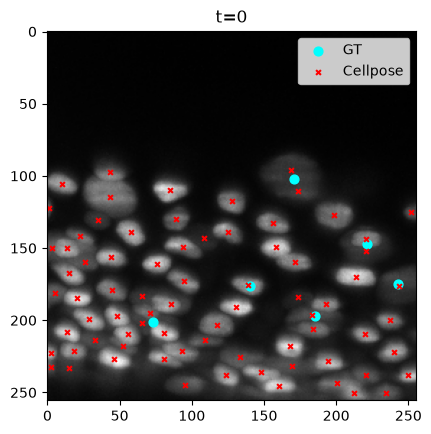

In [16]:
plt.imshow(img, cmap="gray")
plt.scatter(gt[:, 0], gt[:, 1], c="cyan", s=40, label="GT")
plt.scatter(det[:, 0], det[:, 1], c="red", s=12, marker="x", label="Cellpose")
plt.legend()
plt.title(f"t={t}")
plt.show()